# EDA — Contratación pública en Cali | Grupo 6

## Objetivo
Identificar y priorizar cinco segmentos de contratación pública que, con base en datos históricos de SECOP II, combinen **demanda**, **valor económico**, **recurrencia** y **baja competencia observable**.

> **Importante:** este EDA es descriptivo/exploratorio. El índice de oportunidad **no es una probabilidad de ganar contratos ni una predicción**. Sirve para priorizar segmentos que posteriormente deben validarse comercialmente.

### Pregunta SMART operacionalizada
**¿Cuáles son los cinco segmentos de contratación pública de las entidades estatales de Cali que, con base en los datos históricos de SECOP II, presentan la combinación más favorable de demanda, valor económico, recurrencia y baja competencia observable, para priorizar la gestión comercial durante los próximos 12 meses?**


## 1. Criterio de oportunidad

Se consideran oportunidades las siguientes modalidades **cuando aparecen en el archivo**:

- Mínima cuantía.
- Contratación mínima cuantía.
- Licitación pública.
- Licitación pública obra pública.
- Selección abreviada de menor cuantía.
- Selección abreviada subasta inversa.

Se excluyen explícitamente:

- Contratación directa.
- Evento/solicitud de cotización.
- Procesos cancelados o en borrador para la base analítica final.
- Procesos sin categoría principal identificable.

La unidad de análisis es el **ID del Proceso único**, para evitar contar varias veces un mismo proceso.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

CSV = "Contratos_Secop_II_20260912.csv"
df = pd.read_csv(CSV, low_memory=False)

df = df.loc[
    df["Ciudad Entidad"]
    .astype("string")
    .str.strip()
    .str.casefold()
    .eq("cali")
    .fillna(False)
].copy()

print("Dimensiones del archivo:", df.shape)
print("Ciudades encontradas:", df["Ciudad Entidad"].value_counts().head(10).to_dict())



Dimensiones del archivo: (104913, 58)
Ciudades encontradas: {'Cali': 104913}


## 2. Filtrado y calidad de datos

El archivo analizado contiene 104.913 filas y, en este corte, todas las filas tienen `Ciudad Entidad = Cali`.

El dataset contiene varias filas asociadas a procesos, por lo que se deduplica por `ID del Proceso` antes de calcular indicadores de demanda, valor y competencia.


In [ ]:
opportunity_modalities = [
    "Mínima cuantía",
    "Contratación mínima cuantía",
    "Licitación pública",
    "Licitación pública obra pública",
    "Selección Abreviada de Menor Cuantía",
    "Selección abreviada subasta inversa",
]

work = df[df["Modalidad de Contratacion"].isin(opportunity_modalities)].copy()

quotation_text = (
    work["Modalidad de Contratacion"].astype(str).str.contains("cotiz", case=False, na=False)
    | work["Justificación Modalidad de Contratación"].astype(str).str.contains(
        "evento de cotización|solicitud de cotización", case=False, regex=True, na=False
    )
    | work["Nombre del Procedimiento"].astype(str).str.contains(
        "evento de cotización|solicitud de cotización", case=False, regex=True, na=False
    )
)
work = work[~quotation_text].copy()

print("Procesos/registros tras filtro de modalidades:", len(work))
print(work["Modalidad de Contratacion"].value_counts())

processes = work.drop_duplicates("ID del Proceso").copy()

def parse_money(series):
    return pd.to_numeric(
        series.astype(str).str.replace(r"[^0-9-]", "", regex=True),
        errors="coerce"
    )

processes["Precio_Base"] = parse_money(processes["Precio Base"])
processes["Fecha_Publicacion"] = pd.to_datetime(
    processes["Fecha de Publicacion del Proceso"], errors="coerce"
)
processes["Año"] = processes["Fecha_Publicacion"].dt.year

print("\nProcesos únicos:", processes["ID del Proceso"].nunique())
print("Precio base faltante:", processes["Precio_Base"].isna().mean())
print("Fecha faltante:", processes["Fecha_Publicacion"].isna().mean())


Procesos/registros tras filtro de modalidades: 1848
Modalidad de Contratacion
Selección Abreviada de Menor Cuantía    1191
Mínima cuantía                           596
Licitación pública                        55
Selección abreviada subasta inversa        6
Name: count, dtype: int64

Procesos únicos: 1458
Precio base faltante: 0.0
Fecha faltante: 0.0205761316872428


## 3. Construcción de la base analítica

Para evitar que situaciones administrativas distorsionen la comparación, se excluyen procesos `Cancelado` y `Borrador`. También se excluyen categorías vacías o `UNSPECIFIED`.

### Competencia observable
Se utiliza `Proveedores Unicos con Respuestas`.

**No se interpreta cero como “cero competencia”.** La competencia promedio se calcula solamente en procesos con más de cero proveedores con respuesta. Adicionalmente se reporta la cobertura: proporción de procesos en los que fue observable al menos un proveedor con respuesta.


In [ ]:
analysis = processes[
    ~processes["Estado del Procedimiento"].isin(["Cancelado", "Borrador"])
].copy()

analysis = analysis[
    analysis["Codigo Principal de Categoria"].notna()
    & ~analysis["Codigo Principal de Categoria"].astype(str).str.strip().str.upper().isin(
        ["", "NAN", "UNSPECIFIED"]
    )
].copy()

print("Base analítica final:", len(analysis), "procesos")
print("Años disponibles:", int(analysis["Año"].min()), "a", int(analysis["Año"].max()))
print("Número de años:", analysis["Año"].nunique())


Base analítica final: 1234 procesos
Años disponibles: 2017 a 2026
Número de años: 10


## 4. Demanda por modalidad

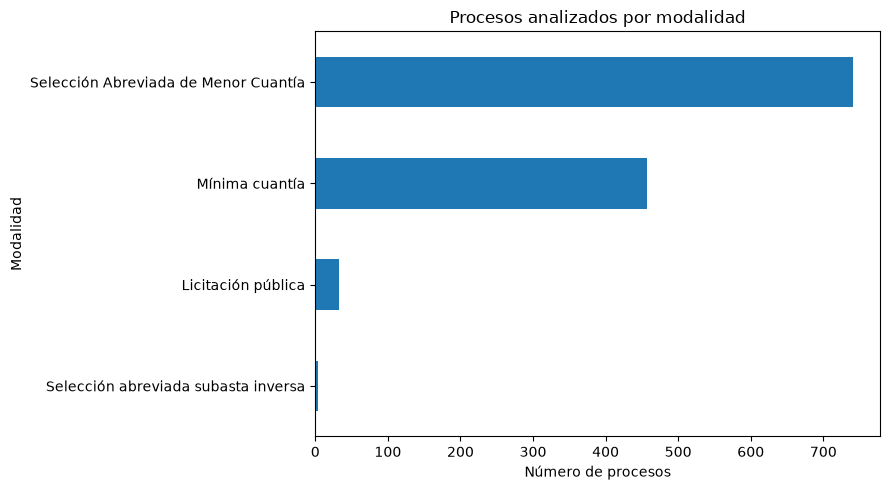

Modalidad de Contratacion
Selección abreviada subasta inversa       4
Licitación pública                       32
Mínima cuantía                          457
Selección Abreviada de Menor Cuantía    741
Name: count, dtype: int64


In [ ]:
modalidad = analysis["Modalidad de Contratacion"].value_counts().sort_values()

ax = modalidad.plot(kind="barh", figsize=(9,5))
ax.set_title("Procesos analizados por modalidad")
ax.set_xlabel("Número de procesos")
ax.set_ylabel("Modalidad")
plt.tight_layout()
plt.show()

print(modalidad)


**Lectura:** la población está dominada por selección abreviada de menor cuantía y mínima cuantía. En el corte disponible no aparecen registros de “licitación pública obra pública” ni “contratación mínima cuantía”; por tanto, no se inventan datos para esas modalidades.

## 5. Evolución anual de la demanda

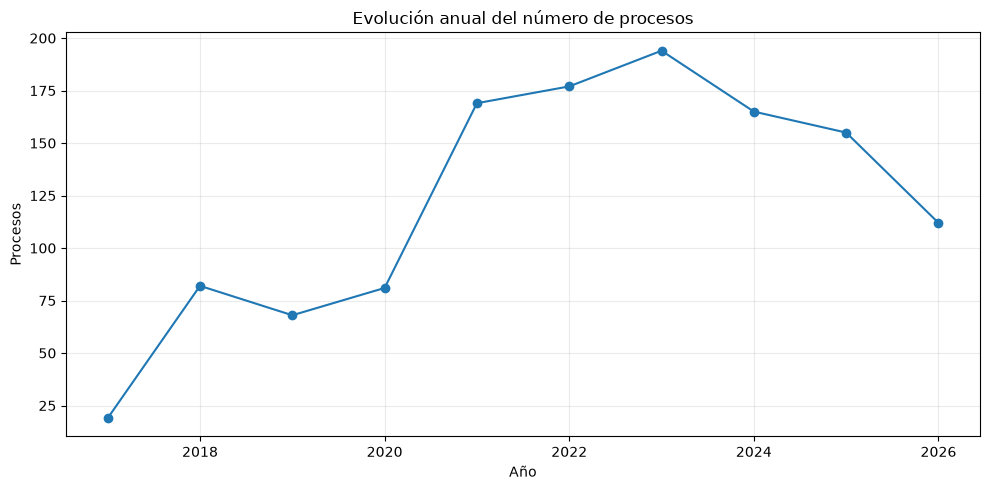

,Año,procesos,valor_estimado
0,"2,017.00",19,3625000000
1,"2,018.00",82,42203608760
2,"2,019.00",68,65368158941
3,"2,020.00",81,55715456620
4,"2,021.00",169,179953018596
5,"2,022.00",177,56184199340
6,"2,023.00",194,77136047261
7,"2,024.00",165,106557385966
8,"2,025.00",155,114600637798
9,"2,026.00",112,46031098437


In [ ]:
temporal = (
    analysis.groupby("Año")
    .agg(procesos=("ID del Proceso", "nunique"),
         valor_estimado=("Precio_Base", "sum"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(temporal["Año"], temporal["procesos"], marker="o")
ax.set_title("Evolución anual del número de procesos")
ax.set_xlabel("Año")
ax.set_ylabel("Procesos")
ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

display(temporal)


## 6. Segmentos de contratación

In [ ]:
segment_demand = (
    analysis.groupby("Codigo Principal de Categoria")
    .agg(
        procesos=("ID del Proceso", "nunique"),
        valor_estimado=("Precio_Base", "sum"),
        valor_mediano=("Precio_Base", "median"),
        entidades=("Entidad", "nunique")
    )
    .sort_values("procesos", ascending=False)
)

display(segment_demand.head(10))


,procesos,valor_estimado,valor_mediano,entidades
Codigo Principal de Categoria,,,,
V1.85101706,255,82913983946,"130,000,000.00",1
V1.85101500,187,122911512107,"262,000,000.00",5
V1.85121700,63,46912982369,"350,000,000.00",3
V1.85101501,45,21400691218,"650,000,000.00",2
V1.85121600,29,19236900304,"500,000,000.00",4
V1.85101700,24,174903961444,"5,150,398,915.00",3
V1.85101600,23,13887795800,"490,000,000.00",2
V1.85101605,17,9072175792,"333,587,896.00",2
V1.85121808,17,14674927050,"200,000,000.00",3


## 7. Valor económico

`Precio Base` se utiliza como **proxy del tamaño económico estimado del proceso**, no como ingreso efectivamente obtenido por un proveedor.

Se evita sumar directamente `Valor Total Adjudicacion` sobre filas repetidas, porque una exportación de procesos puede representar estructuras con lotes/proveedores y generar duplicaciones.


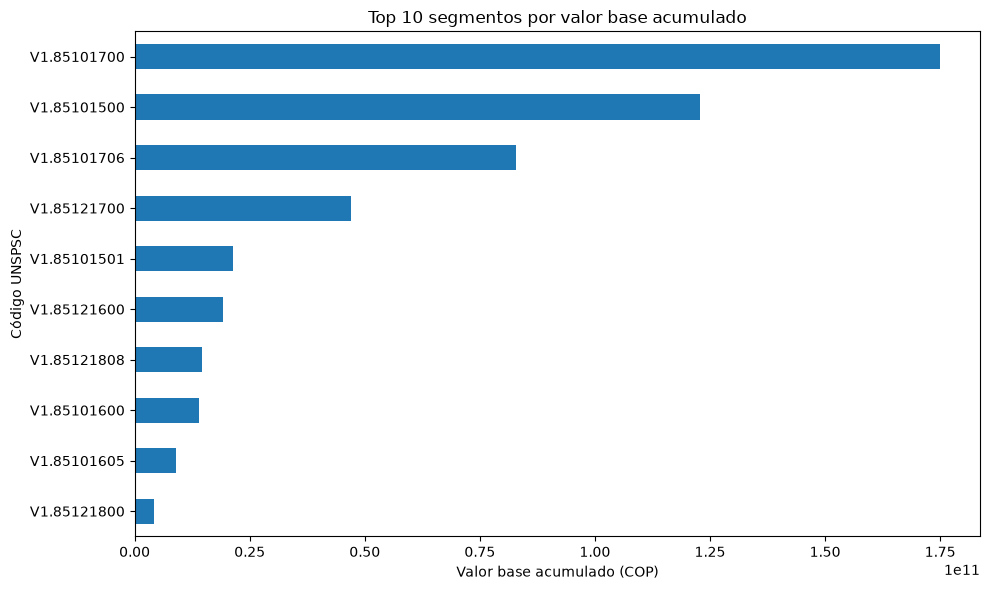

In [ ]:
top_value = segment_demand.head(10).sort_values("valor_estimado")

ax = top_value["valor_estimado"].plot(kind="barh", figsize=(10,6))
ax.set_title("Top 10 segmentos por valor base acumulado")
ax.set_xlabel("Valor base acumulado (COP)")
ax.set_ylabel("Código UNSPSC")
plt.tight_layout()
plt.show()


## 8. Recurrencia y competencia observable

In [ ]:
n_years = int(analysis["Año"].nunique())

segments = (
    analysis.groupby("Codigo Principal de Categoria")
    .agg(
        procesos=("ID del Proceso", "nunique"),
        valor_estimado=("Precio_Base", "sum"),
        valor_mediano=("Precio_Base", "median"),
        entidades=("Entidad", "nunique"),
        periodos=("Año", "nunique"),
    )
    .reset_index()
)

comp = (
    analysis.loc[analysis["Proveedores Unicos con Respuestas"] > 0]
    .groupby("Codigo Principal de Categoria")["Proveedores Unicos con Respuestas"]
    .mean()
    .rename("competencia_promedio")
)

coverage = (
    analysis.groupby("Codigo Principal de Categoria")["Proveedores Unicos con Respuestas"]
    .apply(lambda s: (s > 0).mean())
    .rename("cobertura_competencia")
)

segments = segments.merge(comp, on="Codigo Principal de Categoria", how="left")
segments = segments.merge(coverage, on="Codigo Principal de Categoria", how="left")
segments["recurrencia"] = segments["periodos"] / n_years

display(
    segments.sort_values(["procesos", "valor_estimado"], ascending=False).head(10)
)


,Codigo Principal de Categoria,procesos,valor_estimado,valor_mediano,entidades,periodos,competencia_promedio,cobertura_competencia,recurrencia
135,V1.85101706,255,82913983946,"130,000,000.00",1,6,1.44,0.58,0.60
125,V1.85101500,187,122911512107,"262,000,000.00",5,10,1.87,0.49,1.00
150,V1.85121700,63,46912982369,"350,000,000.00",3,9,1.96,0.40,0.90
126,V1.85101501,45,21400691218,"650,000,000.00",2,5,1.42,0.27,0.50
141,V1.85121600,29,19236900304,"500,000,000.00",4,5,1.17,0.21,0.50
133,V1.85101700,24,174903961444,"5,150,398,915.00",3,5,1.14,0.29,0.50
129,V1.85101600,23,13887795800,"490,000,000.00",2,6,2.50,0.35,0.60
156,V1.85121808,17,14674927050,"200,000,000.00",3,7,1.83,0.35,0.70
132,V1.85101605,17,9072175792,"333,587,896.00",2,4,3.00,0.18,0.40
64,V1.78111800,16,7006151986,"195,565,565.00",5,5,2.00,0.31,0.50


## 9. Índice exploratorio de oportunidad

Para no permitir que únicamente los valores monetarios extremos dominen el resultado, se utilizan **percentiles**.

Ponderaciones:

- 30% demanda: número de procesos.
- 30% valor económico: valor base acumulado.
- 20% recurrencia: años con presencia / años disponibles.
- 20% baja competencia observable: inverso del percentil de competencia promedio.

Se exige un mínimo de **5 procesos por segmento**.

El índice es una herramienta de priorización exploratoria; no representa una predicción ni una probabilidad de adjudicación.


In [ ]:
eligible = segments[segments["procesos"] >= 5].copy()

for col in ["procesos", "valor_estimado", "competencia_promedio"]:
    eligible[f"{col}_pct"] = eligible[col].rank(pct=True, na_option="keep")

eligible["competencia_baja_score"] = 1 - eligible["competencia_promedio_pct"].fillna(1)

eligible["indice_oportunidad"] = 100 * (
    0.30 * eligible["procesos_pct"]
    + 0.30 * eligible["valor_estimado_pct"]
    + 0.20 * eligible["recurrencia"]
    + 0.20 * eligible["competencia_baja_score"]
)

category_names = {
    "V1.85101500": "Centros de salud",
    "V1.85121700": "Servicios de prestadores especialistas de servicios de salud",
    "V1.85101700": "Servicios de administración de salud",
    "V1.85101706": "Servicios tradicionales de atención de salud",
    "V1.85121600": "Servicios de médicos / práctica médica de atención primaria",
}

eligible["Nombre del segmento"] = (
    eligible["Codigo Principal de Categoria"].map(category_names)
    .fillna("Segmento UNSPSC no mapeado")
)

top5 = eligible.sort_values(
    ["indice_oportunidad", "procesos", "valor_estimado"],
    ascending=[False, False, False]
).head(5).copy()

result = top5[
    [
        "Codigo Principal de Categoria", "Nombre del segmento", "procesos",
        "valor_estimado", "valor_mediano", "entidades",
        "competencia_promedio", "cobertura_competencia",
        "periodos", "recurrencia", "indice_oportunidad"
    ]
].copy()

display(result)


,Codigo Principal de Categoria,Nombre del segmento,procesos,valor_estimado,valor_mediano,entidades,competencia_promedio,cobertura_competencia,periodos,recurrencia,indice_oportunidad
125,V1.85101500,Centros de salud,187,122911512107,"262,000,000.00",5,1.87,0.49,10,1.00,90.87
150,V1.85121700,Servicios de prestadores especialistas de serv...,63,46912982369,"350,000,000.00",3,1.96,0.40,9,0.90,86.48
133,V1.85101700,Servicios de administración de salud,24,174903961444,"5,150,398,915.00",3,1.14,0.29,5,0.50,85.00
135,V1.85101706,Servicios tradicionales de atención de salud,255,82913983946,"130,000,000.00",1,1.44,0.58,6,0.60,84.61
141,V1.85121600,Servicios de médicos / práctica médica de aten...,29,19236900304,"500,000,000.00",4,1.17,0.21,5,0.50,80.43


## 10. Mapa demanda–competencia

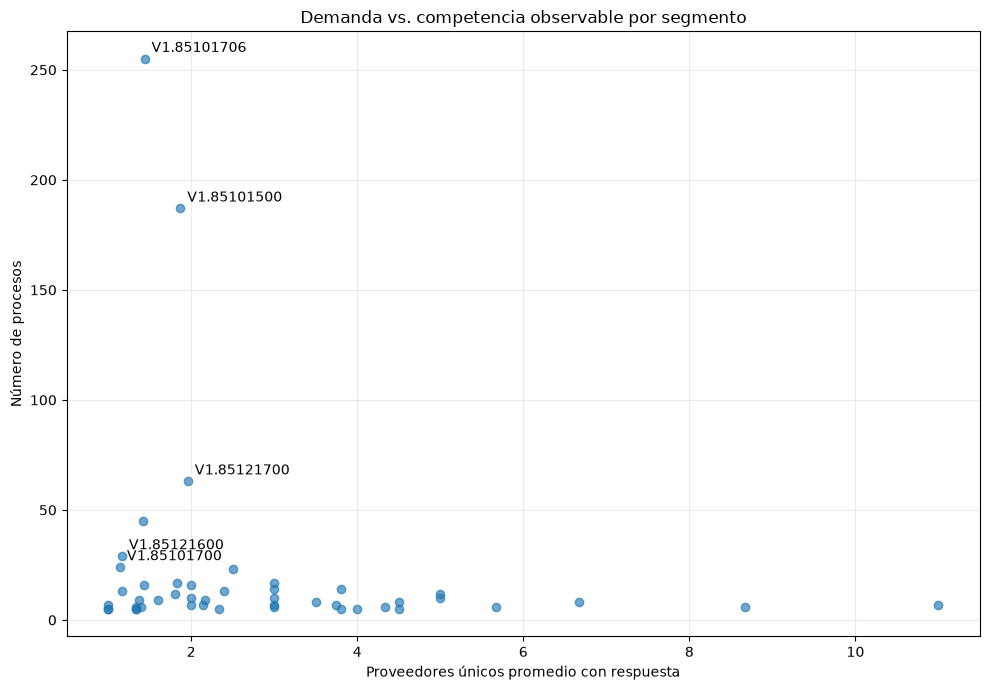

In [ ]:
plot_data = eligible.dropna(subset=["competencia_promedio"]).copy()

fig, ax = plt.subplots(figsize=(10,7))
ax.scatter(
    plot_data["competencia_promedio"],
    plot_data["procesos"],
    alpha=.65
)

for _, r in top5.iterrows():
    ax.annotate(
        r["Codigo Principal de Categoria"],
        (r["competencia_promedio"], r["procesos"]),
        xytext=(5,5),
        textcoords="offset points"
    )

ax.set_title("Demanda vs. competencia observable por segmento")
ax.set_xlabel("Proveedores únicos promedio con respuesta")
ax.set_ylabel("Número de procesos")
ax.grid(alpha=.25)
plt.tight_layout()
plt.show()


## 11. Evidencia de los cinco segmentos prioritarios

Los códigos se traducen a nombres legibles para la presentación. La clasificación UNSPSC es un lenguaje estándar de bienes y servicios utilizado en contratación pública; los nombres deben entenderse como descripciones del segmento, no como una afirmación de que todos los procesos sean idénticos.

### Resultado


In [ ]:
display(result.style.format({
    "valor_estimado": "${:,.0f}",
    "valor_mediano": "${:,.0f}",
    "competencia_promedio": "{:.2f}",
    "cobertura_competencia": "{:.1%}",
    "recurrencia": "{:.1%}",
    "indice_oportunidad": "{:.2f}",
}))

print("\nProcedimientos representativos por segmento:")
for code in top5["Codigo Principal de Categoria"]:
    print("\n", code, "-", category_names.get(code, "Segmento no mapeado"))
    cols = ["Nombre del Procedimiento", "Entidad", "Precio_Base"]
    display(
        analysis[analysis["Codigo Principal de Categoria"] == code][cols]
        .dropna(subset=["Nombre del Procedimiento"])
        .sort_values("Precio_Base", ascending=False)
        .head(3)
    )


,Codigo Principal de Categoria,Nombre del segmento,procesos,valor_estimado,valor_mediano,entidades,competencia_promedio,cobertura_competencia,periodos,recurrencia,indice_oportunidad
125,V1.85101500,Centros de salud,187,"$122,911,512,107","$262,000,000",5,1.87,49.2%,10,100.0%,90.87
150,V1.85121700,Servicios de prestadores especialistas de servicios de salud,63,"$46,912,982,369","$350,000,000",3,1.96,39.7%,9,90.0%,86.48
133,V1.85101700,Servicios de administración de salud,24,"$174,903,961,444","$5,150,398,915",3,1.14,29.2%,5,50.0%,85.00
135,V1.85101706,Servicios tradicionales de atención de salud,255,"$82,913,983,946","$130,000,000",1,1.44,58.0%,6,60.0%,84.61
141,V1.85121600,Servicios de médicos / práctica médica de atención primaria,29,"$19,236,900,304","$500,000,000",4,1.17,20.7%,5,50.0%,80.43



Procedimientos representativos por segmento:

 V1.85101500 - Centros de salud


,Nombre del Procedimiento,Entidad,Precio_Base
1608404,PN RASES4 SA MC SS 007/2021 (Manifestación de ...,REGIONAL DE ASEGURAMIENTO EN SALUD No. 4,7000000000
1612291,PN RASES4 SA MC SS 007/2021,REGIONAL DE ASEGURAMIENTO EN SALUD No. 4,7000000000
1665235,PN RASES4 SA MC SS 0-032/2020 (Manifestación d...,REGIONAL DE ASEGURAMIENTO EN SALUD No. 4,6218117990



 V1.85121700 - Servicios de prestadores especialistas de servicios de salud


,Nombre del Procedimiento,Entidad,Precio_Base
1664143,PN RASES4 SA MC SS 0-032/2020 (Manifestación d...,REGIONAL DE ASEGURAMIENTO EN SALUD No. 4,6218117990
1736949,SERVICIOS DE SALUD DE MEDIANA Y ALTA COMPLEJIDAD,REGIONAL DE ASEGURAMIENTO EN SALUD No. 4,3383213616
827975,PN UPRES VALLE SA MC SS 287/2024 MEDICINA GENE...,UPRES VALLE,3329138680


...

,Nombre del Procedimiento,Entidad,Precio_Base
374009,PLAN ADICIONAL DE SALUD PARA TODOS LOS PENSION...,GOBERNACION DEL VALLE DEL CAUCA - DADI,26984183157
382475,PLAN ADICIONAL DE SALUD PARA TODOS LOS PENSION...,GOBERNACION DEL VALLE DEL CAUCA - DADI,26984183157
1529531,PLAN ADICIONAL DE SALUD PARA TODOS LOS PENSION...,GOBERNACION DEL VALLE DEL CAUCA - DADI,13166346000



 V1.85101706 - Servicios tradicionales de atención de salud


,Nombre del Procedimiento,Entidad,Precio_Base
1605793,PN RASES4 SA MC SS 007/2021 (Manifestación de ...,REGIONAL DE ASEGURAMIENTO EN SALUD No. 4,7000000000
112867,PN RASES4 SA MC SS 102/2026 (Manifestación de ...,REGIONAL DE ASEGURAMIENTO EN SALUD No. 4,3072000000
1586991,PN RASES4 SA MC SS 062/2021 (Manifestación de ...,REGIONAL DE ASEGURAMIENTO EN SALUD No. 4,2330000000



 V1.85121600 - Servicios de médicos / práctica médica de atención primaria


,Nombre del Procedimiento,Entidad,Precio_Base
1367988,PRESTACIÓN DE SERVICIOS DE MEDICINA GENERAL; M...,UPRES VALLE,1890201471
1359212,PRESTACIÓN DE SERVICIOS DE MEDICINA GENERAL; M...,UPRES VALLE,1890201471
922753,PN UPRES VALLE SA MC SS 235/2024 MEDICINA GENE...,UPRES VALLE,1887478048


## 12. Respuesta a la pregunta SMART

Con el corte analizado, los cinco segmentos que obtienen el mayor índice exploratorio son:

1. **V1.85101500 — Centros de salud**
2. **V1.85121700 — Servicios de prestadores especialistas de servicios de salud**
3. **V1.85101700 — Servicios de administración de salud**
4. **V1.85101706 — Servicios tradicionales de atención de salud**
5. **V1.85121600 — Servicios de médicos / práctica médica de atención primaria**

Estos segmentos son candidatos a **priorización comercial**, porque combinan demanda, magnitud económica, presencia en varios años y un nivel de competencia observable relativamente bajo frente al resto de segmentos elegibles.

### Interpretación correcta
El resultado **no significa que sean contratos fáciles de ganar**. Una competencia baja puede estar asociada con requisitos técnicos, barreras de entrada, especialización, capacidad instalada, habilitaciones o condiciones particulares del mercado. Por ello, el EDA sirve para seleccionar dónde investigar y no para garantizar una oportunidad comercial.

### Limitación geográfica
El filtro se realizó por `Ciudad Entidad = Cali`. Esto identifica entidades cuya ciudad registrada es Cali, pero no garantiza que la ejecución de cada contrato ocurra físicamente en Cali. Esta limitación debe declararse en la presentación.


## 13. Conclusiones

- El archivo contiene **104.913 filas** y, después de aplicar las modalidades definidas y deduplicar por proceso, se obtiene una población de **1.458 procesos de oportunidad** antes de depuración.
- Después de excluir cancelados, borradores y categorías no identificables, la base analítica queda en **1.234 procesos**.
- La demanda está concentrada principalmente en **Selección Abreviada de Menor Cuantía** y **Mínima cuantía**.
- Los cinco segmentos priorizados están relacionados con servicios de salud, pero se debe validar comercialmente cada segmento antes de considerarlo una oportunidad real.
- La metodología responde a la pregunta SMART mediante evidencia cuantitativa y un criterio reproducible de priorización.


## 14. Limitaciones y recomendaciones

1. `Proveedores Unicos con Respuestas` mide competencia observable, no necesariamente todos los competidores potenciales.
2. Los ceros de proveedores no se interpretan automáticamente como ausencia de competencia.
3. `Precio Base` es una estimación del tamaño del proceso, no ingreso realizado.
4. El índice depende de las ponderaciones elegidas; por ello debe considerarse exploratorio.
5. El análisis no predice contratos futuros; para una etapa predictiva se requeriría modelar la ocurrencia/valor de futuros procesos y validar temporalmente el modelo.
6. Para uso empresarial real, conviene incorporar barreras de entrada, requisitos habilitantes, capacidad del proveedor y margen esperado.
